# Phase 6 — Export Final Enrichi

**Input** : `laptop_phase4.csv` + `association_rules.csv` + `association_rules.json` + `anomalies_report.json`  
**Output** : `laptop_final.csv` + `dashboard_data.json` + rapport récapitulatif

Cette phase consolide **tous les résultats** des phases précédentes en un seul fichier propre,  
prêt à être consommé par le **backend Django** pour alimenter le dashboard React.

Étapes :
1. Chargement & vérification de tous les outputs
2. Consolidation en un seul DataFrame enrichi
3. Statistiques globales finales
4. Construction du `dashboard_data.json` (pour Django)
5. Export CSV final
6. Rapport récapitulatif du pipeline complet

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json, os, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11

INPUTS_DIR = '../inputs/'
OUTPUT_DIR = '../outputs/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('✅ Setup terminé')

✅ Setup terminé


## 1. Chargement & Vérification de tous les outputs

In [2]:
# --- Charger le CSV le plus avancé disponible ---
for phase in ['laptop_phase4.csv', 'laptop_phase3.csv', 'laptop_phase2.csv', 'laptop_phase1.csv']:
    path = os.path.join(INPUTS_DIR, phase)
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f'✅ Chargé : {phase}  ({df.shape})')
        break

print(f'\nColonnes disponibles :')
print(list(df.columns))

✅ Chargé : laptop_phase4.csv  ((50, 24))

Colonnes disponibles :
['title', 'brand', 'price', 'price_usd', 'currency', 'platform', 'ram_gb', 'storage_gb', 'category', 'search_query', 'url', 'scraped_date', 'price_range', 'cluster_kmeans', 'cluster_kmeans_label', 'cluster_dbscan', 'pca_x', 'pca_y', 'iso_score', 'lof_score', 'anomaly_score', 'is_anomaly', 'is_anomaly_soft', 'anomaly_type']


In [3]:
# --- Charger les JSONs des phases précédentes ---
def load_json_safe(path):
    if os.path.exists(path):
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        print(f'✅ {os.path.basename(path)}')
        return data
    else:
        print(f'❌ {os.path.basename(path)}  ABSENT')
        return {}

stats_summary    = load_json_safe(os.path.join(OUTPUT_DIR, 'stats_summary.json'))
anomalies_report = load_json_safe(os.path.join(OUTPUT_DIR, 'anomalies_report.json'))
assoc_rules      = load_json_safe(os.path.join(OUTPUT_DIR, 'association_rules.json'))

# --- Charger le CSV des règles si disponible ---
rules_csv_path = os.path.join(OUTPUT_DIR, 'association_rules.csv')
if os.path.exists(rules_csv_path):
    df_rules = pd.read_csv(rules_csv_path)
    print(f'✅ association_rules.csv  ({len(df_rules)} règles)')
else:
    df_rules = pd.DataFrame()
    print('❌ association_rules.csv  ABSENT')

✅ stats_summary.json
✅ anomalies_report.json
✅ association_rules.json
✅ association_rules.csv  (409 règles)


## 2. Consolidation du DataFrame final

In [4]:
df_final = df.copy()

# --- 2.1 S'assurer que price_range est présent ---
if 'price_range' not in df_final.columns:
    Q1 = df_final['price'].quantile(0.25)
    Q3 = df_final['price'].quantile(0.75)
    df_final['price_range'] = pd.cut(
        df_final['price'],
        bins=[0, Q1, Q3, float('inf')],
        labels=['bas_de_gamme', 'milieu_de_gamme', 'haut_de_gamme']
    ).astype(str)
    print(f'price_range recalculé (Q1={Q1:.0f}, Q3={Q3:.0f} MAD)')

# --- 2.2 Gamme finale : K-Means si dispo, sinon price_range ---
if 'cluster_kmeans_label' in df_final.columns and df_final['cluster_kmeans_label'].notna().sum() > 0:
    df_final['gamme_finale'] = df_final['cluster_kmeans_label']
    print('gamme_finale ← cluster_kmeans_label (K-Means Phase 3)')
else:
    df_final['gamme_finale'] = df_final['price_range']
    print('gamme_finale ← price_range (Q1/Q3 Phase 2)')

# --- 2.3 Colonnes anomalie ---
if 'is_anomaly' not in df_final.columns:
    df_final['is_anomaly']   = 0
    df_final['anomaly_type'] = 'normal'
    print('is_anomaly absent → mis à 0 (Phase 4 non executée)')

# --- 2.4 Colonnes discrétisées (si absentes) ---
def discretize_ram(r):
    if pd.isna(r):  return 'inconnu'
    elif r <= 4:    return '<=4Go'
    elif r <= 8:    return '8Go'
    elif r <= 16:   return '16Go'
    else:           return '>=32Go'

def discretize_storage(s):
    if pd.isna(s):   return 'inconnu'
    elif s <= 256:   return '<=256Go'
    elif s <= 512:   return '512Go'
    elif s <= 1024:  return '1To'
    else:            return '>1To'

if 'ram_cat' not in df_final.columns:
    df_final['ram_cat'] = df_final['ram_gb'].apply(discretize_ram)
if 'storage_cat' not in df_final.columns:
    df_final['storage_cat'] = df_final['storage_gb'].apply(discretize_storage)

print(f'\nShape final : {df_final.shape}')
print(f'Colonnes    : {list(df_final.columns)}')

gamme_finale ← cluster_kmeans_label (K-Means Phase 3)

Shape final : (50, 27)
Colonnes    : ['title', 'brand', 'price', 'price_usd', 'currency', 'platform', 'ram_gb', 'storage_gb', 'category', 'search_query', 'url', 'scraped_date', 'price_range', 'cluster_kmeans', 'cluster_kmeans_label', 'cluster_dbscan', 'pca_x', 'pca_y', 'iso_score', 'lof_score', 'anomaly_score', 'is_anomaly', 'is_anomaly_soft', 'anomaly_type', 'gamme_finale', 'ram_cat', 'storage_cat']


In [5]:
# --- 2.5 Sélection et ordre des colonnes finales ---
FINAL_COLS = [
    # Identité produit
    'title', 'brand', 'platform', 'url',
    # Prix
    'price', 'price_usd', 'currency',
    # Specs techniques
    'ram_gb', 'ram_cat', 'storage_gb', 'storage_cat',
    # Classification
    'price_range', 'gamme_finale',
    # Clustering (Phase 3)
    'cluster_kmeans', 'cluster_kmeans_label',
    'cluster_dbscan',
    # Anomalies (Phase 4)
    'is_anomaly', 'is_anomaly_soft', 'anomaly_type',
    'anomaly_score', 'iso_score', 'lof_score',
    # PCA (Phase 4)
    'pca_x', 'pca_y',
    # Métadonnées
    'category', 'search_query', 'scraped_date'
]

# Garder seulement les colonnes qui existent
cols_present = [c for c in FINAL_COLS if c in df_final.columns]
cols_missing = [c for c in FINAL_COLS if c not in df_final.columns]

df_final = df_final[cols_present].copy()

print(f'Colonnes incluses ({len(cols_present)}) : {cols_present}')
if cols_missing:
    print(f'Colonnes absentes ({len(cols_missing)}) : {cols_missing}')

Colonnes incluses (27) : ['title', 'brand', 'platform', 'url', 'price', 'price_usd', 'currency', 'ram_gb', 'ram_cat', 'storage_gb', 'storage_cat', 'price_range', 'gamme_finale', 'cluster_kmeans', 'cluster_kmeans_label', 'cluster_dbscan', 'is_anomaly', 'is_anomaly_soft', 'anomaly_type', 'anomaly_score', 'iso_score', 'lof_score', 'pca_x', 'pca_y', 'category', 'search_query', 'scraped_date']


## 3. Statistiques Globales Finales

In [6]:
print('=' * 60)
print('  STATISTIQUES GLOBALES DU PIPELINE')
print('=' * 60)
print(f'  Produits total         : {len(df_final)}')
print(f'  Plateformes            : {df_final["platform"].nunique()} — {list(df_final["platform"].unique())}')
print(f'  Marques                : {df_final["brand"].nunique()}')
print()
print('  --- PRIX (MAD) ---')
print(f'  Min     : {df_final["price"].min():,.0f}')
print(f'  Médiane : {df_final["price"].median():,.0f}')
print(f'  Moyenne : {df_final["price"].mean():,.0f}')
print(f'  Max     : {df_final["price"].max():,.0f}')
print(f'  Écart-type : {df_final["price"].std():,.0f}')
print()
print('  --- RÉPARTITION GAMMES ---')
print(df_final['gamme_finale'].value_counts().to_string())
print()
print('  --- ANOMALIES ---')
if 'is_anomaly' in df_final.columns:
    n_anom = df_final['is_anomaly'].sum()
    print(f'  Anomalies détectées    : {n_anom} ({n_anom/len(df_final)*100:.1f}%)')
    if 'anomaly_type' in df_final.columns:
        print(df_final['anomaly_type'].value_counts().to_string())
print()
print('  --- COUVERTURE SPECS ---')
print(f'  RAM connue     : {df_final["ram_gb"].notna().sum()}/{len(df_final)} ({df_final["ram_gb"].notna().mean()*100:.0f}%)')
print(f'  Stockage connu : {df_final["storage_gb"].notna().sum()}/{len(df_final)} ({df_final["storage_gb"].notna().mean()*100:.0f}%)')

  STATISTIQUES GLOBALES DU PIPELINE
  Produits total         : 50
  Plateformes            : 2 — ['jumia', 'aliexpress']
  Marques                : 9

  --- PRIX (MAD) ---
  Min     : 2,603
  Médiane : 12,625
  Moyenne : 13,708
  Max     : 45,362
  Écart-type : 9,616

  --- RÉPARTITION GAMMES ---
gamme_finale
bas_de_gamme       35
milieu_de_gamme    10
haut_de_gamme       5

  --- ANOMALIES ---
  Anomalies détectées    : 3 (6.0%)
anomaly_type
normal               47
prix_suspect_haut     2
prix_suspect_bas      1

  --- COUVERTURE SPECS ---
  RAM connue     : 38/50 (76%)
  Stockage connu : 33/50 (66%)


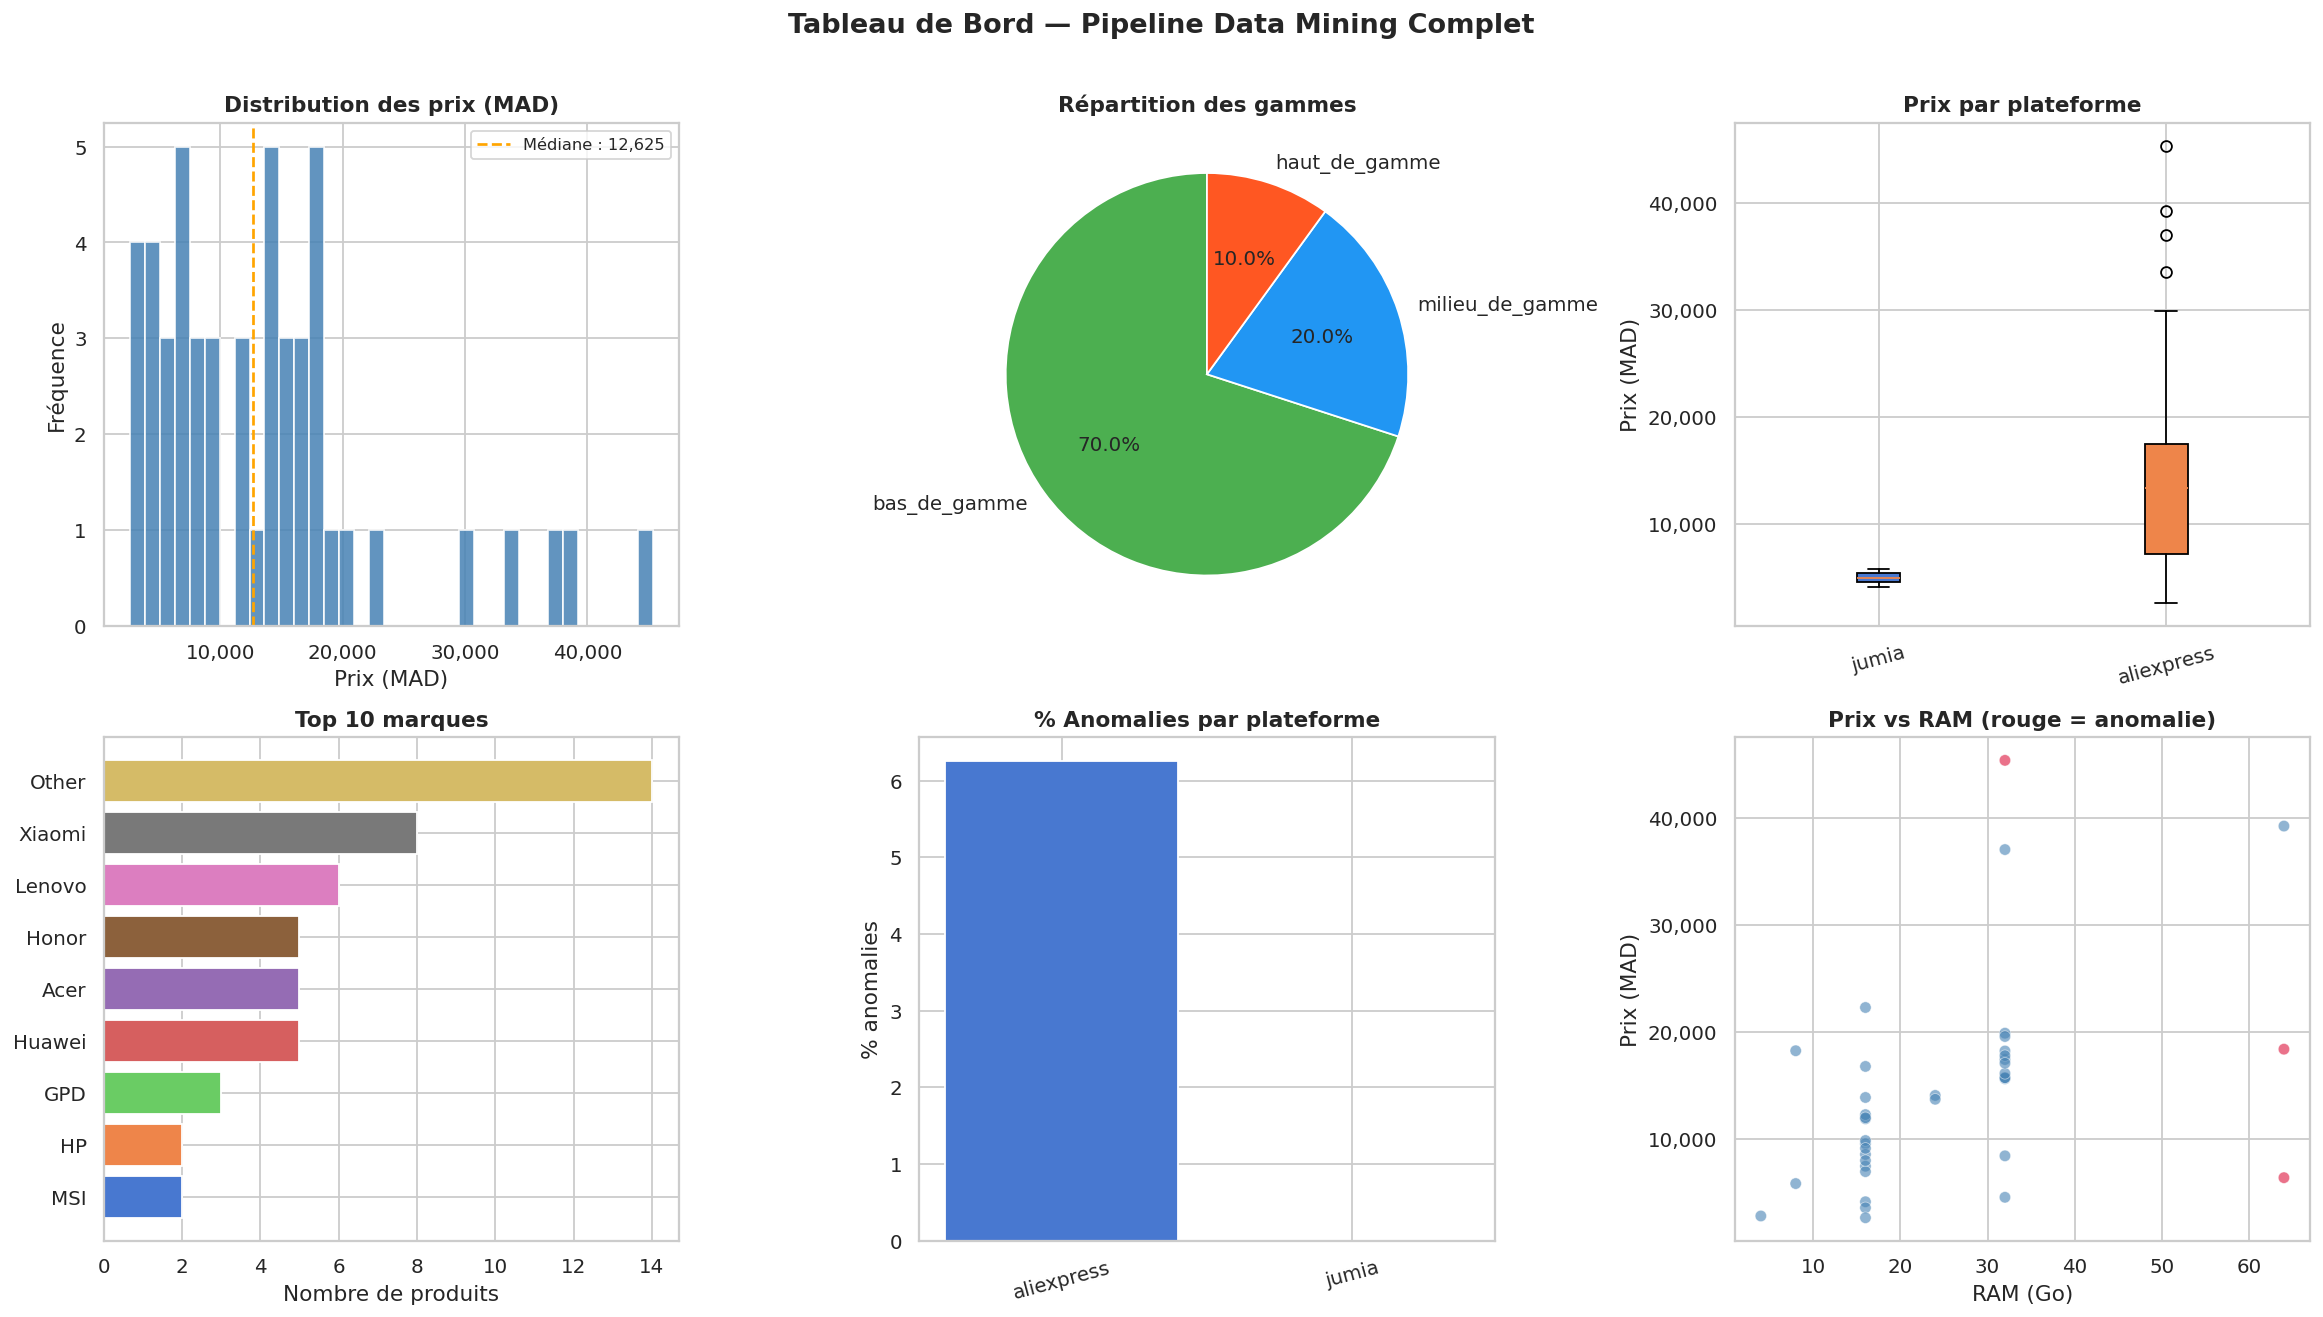

✅ phase6_dashboard_recap.png


In [7]:
# Tableau de bord visuel récapitulatif
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Tableau de Bord — Pipeline Data Mining Complet', fontsize=15, fontweight='bold', y=1.01)

# 1. Distribution des prix
axes[0, 0].hist(df_final['price'], bins=35, color='steelblue', edgecolor='white', alpha=0.85)
axes[0, 0].axvline(df_final['price'].median(), color='orange', linestyle='--', linewidth=1.5,
                    label=f'Médiane : {df_final["price"].median():,.0f}')
axes[0, 0].set_title('Distribution des prix (MAD)', fontweight='bold')
axes[0, 0].set_xlabel('Prix (MAD)'); axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0, 0].legend(fontsize=9)

# 2. Répartition des gammes
gamme_counts = df_final['gamme_finale'].value_counts()
colors_gamme = ['#4CAF50', '#2196F3', '#FF5722', '#9C27B0'][:len(gamme_counts)]
axes[0, 1].pie(gamme_counts.values, labels=gamme_counts.index,
               autopct='%1.1f%%', colors=colors_gamme, startangle=90)
axes[0, 1].set_title('Répartition des gammes', fontweight='bold')

# 3. Prix par plateforme (boxplot)
platforms = df_final['platform'].unique()
data_bp = [df_final[df_final['platform'] == p]['price'].dropna().values for p in platforms]
bp = axes[0, 2].boxplot(data_bp, labels=platforms, patch_artist=True)
for patch, color in zip(bp['boxes'], sns.color_palette('muted', len(platforms))):
    patch.set_facecolor(color)
axes[0, 2].set_title('Prix par plateforme', fontweight='bold')
axes[0, 2].set_ylabel('Prix (MAD)')
axes[0, 2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0, 2].tick_params(axis='x', rotation=15)

# 4. Top marques
brand_counts = df_final['brand'].value_counts().head(10)
axes[1, 0].barh(brand_counts.index[::-1], brand_counts.values[::-1],
                color=sns.color_palette('muted', 10), edgecolor='white')
axes[1, 0].set_title('Top 10 marques', fontweight='bold')
axes[1, 0].set_xlabel('Nombre de produits')

# 5. Anomalies par plateforme
if 'is_anomaly' in df_final.columns:
    anom_pf = df_final.groupby('platform')['is_anomaly'].mean() * 100
    axes[1, 1].bar(anom_pf.index, anom_pf.values,
                   color=sns.color_palette('muted', len(anom_pf)), edgecolor='white')
    axes[1, 1].set_title('% Anomalies par plateforme', fontweight='bold')
    axes[1, 1].set_ylabel('% anomalies')
    axes[1, 1].tick_params(axis='x', rotation=15)

# 6. RAM vs Prix (scatter)
df_plot = df_final.dropna(subset=['ram_gb'])
if 'is_anomaly' in df_plot.columns:
    colors_sc = df_plot['is_anomaly'].map({0: 'steelblue', 1: 'crimson'})
else:
    colors_sc = 'steelblue'
axes[1, 2].scatter(df_plot['ram_gb'], df_plot['price'],
                   c=colors_sc, alpha=0.6, s=40, edgecolors='white', linewidths=0.4)
axes[1, 2].set_title('Prix vs RAM (rouge = anomalie)', fontweight='bold')
axes[1, 2].set_xlabel('RAM (Go)'); axes[1, 2].set_ylabel('Prix (MAD)')
axes[1, 2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase6_dashboard_recap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ phase6_dashboard_recap.png')

## 4. Construction du `dashboard_data.json`

Ce JSON est le **contrat d'interface** entre le Data Mining et le backend Django.  
Il contient toutes les données nécessaires pour alimenter le dashboard React sans que Django  
ait à faire des calculs — il lit et sert directement.

In [8]:
def safe_float(v):
    try: return round(float(v), 2)
    except: return None

def safe_int(v):
    try: return int(v)
    except: return None

# --- 4.1 Stats globales ---
global_stats = {
    'total_products':    len(df_final),
    'platforms':         list(df_final['platform'].unique()),
    'n_brands':          safe_int(df_final['brand'].nunique()),
    'price_min':         safe_float(df_final['price'].min()),
    'price_max':         safe_float(df_final['price'].max()),
    'price_mean':        safe_float(df_final['price'].mean()),
    'price_median':      safe_float(df_final['price'].median()),
    'price_std':         safe_float(df_final['price'].std()),
    'price_q1':          safe_float(df_final['price'].quantile(0.25)),
    'price_q3':          safe_float(df_final['price'].quantile(0.75)),
    'ram_coverage_pct':  safe_float(df_final['ram_gb'].notna().mean() * 100),
    'storage_coverage_pct': safe_float(df_final['storage_gb'].notna().mean() * 100),
}

# --- 4.2 Répartition par plateforme ---
by_platform = []
for platform, grp in df_final.groupby('platform'):
    by_platform.append({
        'platform':    platform,
        'count':       len(grp),
        'price_min':   safe_float(grp['price'].min()),
        'price_median':safe_float(grp['price'].median()),
        'price_mean':  safe_float(grp['price'].mean()),
        'price_max':   safe_float(grp['price'].max()),
        'n_anomalies': safe_int(grp['is_anomaly'].sum()) if 'is_anomaly' in grp.columns else 0,
    })

# --- 4.3 Répartition par gamme ---
by_gamme = []
for gamme, grp in df_final.groupby('gamme_finale'):
    by_gamme.append({
        'gamme':       str(gamme),
        'count':       len(grp),
        'price_min':   safe_float(grp['price'].min()),
        'price_median':safe_float(grp['price'].median()),
        'price_max':   safe_float(grp['price'].max()),
        'top_brands':  grp['brand'].value_counts().head(3).to_dict(),
        'top_platforms': grp['platform'].value_counts().head(3).to_dict(),
    })

# --- 4.4 Top marques ---
top_brands = []
for brand, grp in df_final.groupby('brand'):
    top_brands.append({
        'brand':        brand,
        'count':        len(grp),
        'price_median': safe_float(grp['price'].median()),
        'price_min':    safe_float(grp['price'].min()),
        'price_max':    safe_float(grp['price'].max()),
    })
top_brands = sorted(top_brands, key=lambda x: x['count'], reverse=True)[:15]

# --- 4.5 Anomalies ---
anomalies_list = []
if 'is_anomaly' in df_final.columns:
    anom_df = df_final[df_final['is_anomaly'] == 1]
    for _, row in anom_df.iterrows():
        anomalies_list.append({
            'title':        str(row.get('title', '')),
            'price':        safe_float(row.get('price')),
            'platform':     str(row.get('platform', '')),
            'brand':        str(row.get('brand', '')),
            'anomaly_type': str(row.get('anomaly_type', '')),
            'anomaly_score':safe_float(row.get('anomaly_score')),
        })
    anomalies_list = sorted(anomalies_list, key=lambda x: x['anomaly_score'] or 0, reverse=True)

# --- 4.6 Distribution prix pour histogramme ---
hist_values, hist_edges = np.histogram(df_final['price'].dropna(), bins=30)
price_histogram = {
    'counts': hist_values.tolist(),
    'edges':  [round(e, 2) for e in hist_edges.tolist()]
}

# --- 4.7 Produits pour tableau (tous) ---
products_list = []
for _, row in df_final.iterrows():
    products_list.append({
        'title':         str(row.get('title', '')),
        'brand':         str(row.get('brand', '')),
        'platform':      str(row.get('platform', '')),
        'price':         safe_float(row.get('price')),
        'price_usd':     safe_float(row.get('price_usd')),
        'ram_gb':        safe_float(row.get('ram_gb')),
        'storage_gb':    safe_float(row.get('storage_gb')),
        'ram_cat':       str(row.get('ram_cat', '')),
        'storage_cat':   str(row.get('storage_cat', '')),
        'gamme':         str(row.get('gamme_finale', '')),
        'cluster':       str(row.get('cluster_kmeans_label', '')),
        'is_anomaly':    safe_int(row.get('is_anomaly', 0)),
        'anomaly_type':  str(row.get('anomaly_type', 'normal')),
        'url':           str(row.get('url', '')),
        'pca_x':         safe_float(row.get('pca_x')),
        'pca_y':         safe_float(row.get('pca_y')),
    })

print(f'✅ dashboard_data.json préparé')
print(f'   global_stats     : {len(global_stats)} clés')
print(f'   by_platform      : {len(by_platform)} plateformes')
print(f'   by_gamme         : {len(by_gamme)} gammes')
print(f'   top_brands       : {len(top_brands)} marques')
print(f'   anomalies        : {len(anomalies_list)} produits')
print(f'   products_list    : {len(products_list)} produits')

✅ dashboard_data.json préparé
   global_stats     : 12 clés
   by_platform      : 2 plateformes
   by_gamme         : 3 gammes
   top_brands       : 9 marques
   anomalies        : 3 produits
   products_list    : 50 produits


In [9]:
# --- 4.8 Assembler et exporter le JSON ---

# Règles d'association (depuis phase 5)
rules_gamme_json = assoc_rules.get('top_rules_gamme', [])

dashboard_data = {
    'meta': {
        'generated_at':   str(pd.Timestamp.now()),
        'pipeline_phases': ['Phase1_preprocessing', 'Phase2_stats', 'Phase3_clustering',
                            'Phase4_anomalies', 'Phase5_association_rules', 'Phase6_export'],
        'query':           str(df_final.get('search_query', pd.Series(['laptop'])).iloc[0])
                           if 'search_query' in df_final.columns else 'laptop'
    },
    'global_stats':    global_stats,
    'by_platform':     by_platform,
    'by_gamme':        by_gamme,
    'top_brands':      top_brands,
    'price_histogram': price_histogram,
    'anomalies':       anomalies_list,
    'association_rules': rules_gamme_json[:20],  # top 20 pour le dashboard
    'products':        products_list
}

json_path = os.path.join(OUTPUT_DIR, 'dashboard_data.json')
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(dashboard_data, f, ensure_ascii=False, indent=2)

size_kb = os.path.getsize(json_path) / 1024
print(f'✅ dashboard_data.json  ({size_kb:.1f} KB)')
print(json.dumps(dashboard_data['global_stats'], indent=2))

✅ dashboard_data.json  (40.1 KB)
{
  "total_products": 50,
  "platforms": [
    "jumia",
    "aliexpress"
  ],
  "n_brands": 9,
  "price_min": 2602.93,
  "price_max": 45362.04,
  "price_mean": 13708.18,
  "price_median": 12624.83,
  "price_std": 9615.94,
  "price_q1": 6603.82,
  "price_q3": 17308.22,
  "ram_coverage_pct": 76.0,
  "storage_coverage_pct": 66.0
}


## 5. Export CSV Final

In [10]:
csv_path = os.path.join(INPUTS_DIR, 'laptop_final.csv')
df_final.to_csv(csv_path, index=False, encoding='utf-8')

print(f'✅ laptop_final.csv')
print(f'   Shape     : {df_final.shape}')
print(f'   Colonnes  : {list(df_final.columns)}')
print()
print('Aperçu :')
df_final.head(5)

✅ laptop_final.csv
   Shape     : (50, 27)
   Colonnes  : ['title', 'brand', 'platform', 'url', 'price', 'price_usd', 'currency', 'ram_gb', 'ram_cat', 'storage_gb', 'storage_cat', 'price_range', 'gamme_finale', 'cluster_kmeans', 'cluster_kmeans_label', 'cluster_dbscan', 'is_anomaly', 'is_anomaly_soft', 'anomaly_type', 'anomaly_score', 'iso_score', 'lof_score', 'pca_x', 'pca_y', 'category', 'search_query', 'scraped_date']

Aperçu :


,title,brand,platform,url,price,price_usd,currency,ram_gb,ram_cat,storage_gb,...,is_anomaly_soft,anomaly_type,anomaly_score,iso_score,lof_score,pca_x,pca_y,category,search_query,scraped_date
0,"Hp Laptop 15-FC0075k - Ecran FHD 15,6""- Ryzen5...",HP,jumia,https://www.jumia.ma/hp-laptop-15-fc0075k-ecra...,5799.00,579.90,MAD,8.0,8Go,512.0,...,0,normal,0.269345,-0.537334,1.029518,-1.888046,0.074629,electronics,laptop,2026-05-13
1,Lenovo ThinkPad X13 Yoga Gen 1 Convertible Lap...,Lenovo,jumia,https://www.jumia.ma/lenovo-thinkpad-x13-yoga-...,4099.00,409.90,MAD,16.0,16Go,512.0,...,0,normal,0.161668,-0.467459,1.023207,-1.568627,-0.227634,electronics,laptop,2026-05-13
2,2025 MSI Stealth 18 HX AI Gaming Laptop 18 Inc...,MSI,aliexpress,https://www.aliexpress.com/item/10050116276281...,39218.93,3921.89,MAD,64.0,>=32Go,2048.0,...,1,normal,0.829744,-0.715517,1.887090,4.536421,0.678573,electronics,laptop,2026-05-13
3,GPD Micro PC 2 Beastly Handheld Mini Laptop: 7...,GPD,aliexpress,https://www.aliexpress.com/item/10050121750161...,9521.78,952.18,MAD,16.0,16Go,512.0,...,0,normal,0.085865,-0.418461,1.017910,-1.294305,0.264957,electronics,laptop,2026-05-13
4,FIREBAT 16Pro Gaming Laptop 16Inch AMD Ryzen 7...,Other,aliexpress,https://www.aliexpress.com/item/10050102411682...,13005.25,1300.53,MAD,NaN,inconnu,NaN,...,0,normal,0.006453,-0.388737,0.916282,-0.283400,0.041814,electronics,laptop,2026-05-13


## 6. Rapport Récapitulatif du Pipeline Complet

In [11]:
print('\n' + '=' * 65)
print('   RAPPORT FINAL — PIPELINE DATA MINING COMPLET')
print('   Projet : Market Research & Pricing Analysis')
print('   Matière : Data Mining — Licence IASD 2025/2026')
print('=' * 65)

print('\n📥 PIPELINE :')
print('   laptop.csv')
print('      ↓ Phase 1 — Prétraitement')
print('         Filtrage hors-sujet, doublons, valeurs manquantes')
print('         Extraction brand, ram_gb, storage_gb depuis titres')
print('      ↓ Phase 2 — Analyse Statistique')
print('         Stats descriptives, boxplots, price_range (Q1/Q3)')
print('      ↓ Phase 3 — Clustering')
print('         K-Means + DBSCAN sur (price, ram_gb, storage_gb)')
print('         PCA 2D pour visualisation')
print('      ↓ Phase 4 — Détection d\'Anomalies')
print('         Isolation Forest + LOF, voting strict (AND)')
print('         Qualification : prix_suspect_bas / prix_suspect_haut')
print('      ↓ Phase 5 — Règles d\'Association')
print('         Apriori + FP-Growth (mlxtend)')
print('         Liens : attributs produit → gamme de prix')
print('      ↓ Phase 6 — Export Final')
print('         laptop_final.csv + dashboard_data.json')

print('\n📊 RÉSULTATS :')
print(f'   Produits analysés    : {len(df_final)}')
print(f'   Plateformes          : {list(df_final["platform"].unique())}')
print(f'   Marques              : {df_final["brand"].nunique()}')
print(f'   Prix median          : {df_final["price"].median():,.0f} MAD')
print(f'   RAM couverte         : {df_final["ram_gb"].notna().mean()*100:.0f}%')
print(f'   Stockage couvert     : {df_final["storage_gb"].notna().mean()*100:.0f}%')

if 'is_anomaly' in df_final.columns:
    n_anom = df_final['is_anomaly'].sum()
    print(f'   Anomalies détectées  : {n_anom} ({n_anom/len(df_final)*100:.1f}%)')

if assoc_rules:
    s = assoc_rules.get('stats', {})
    print(f'   Règles d\'association : {s.get("n_rules_total", "?")}')
    print(f'   Règles → gamme       : {s.get("n_rules_gamme", "?")}')

print('\n📁 FICHIERS PRODUITS :')
outputs = [
    ('inputs/', 'laptop_final.csv',        'CSV enrichi final (toutes colonnes)'),
    ('outputs/', 'dashboard_data.json',    'JSON pour Django/React'),
    ('outputs/', 'stats_summary.json',     'Stats descriptives Phase 2'),
    ('outputs/', 'anomalies_report.json',  'Rapport anomalies Phase 4'),
    ('outputs/', 'association_rules.json', 'Règles d\'association Phase 5'),
    ('outputs/', 'association_rules.csv',  'CSV règles Phase 5'),
    ('outputs/', 'phase6_dashboard_recap.png', 'Dashboard visuel récap'),
]
for folder, fname, desc in outputs:
    path = os.path.join('..', folder, fname)
    exists = '✅' if os.path.exists(path) else '❌'
    print(f'   {exists} {fname:<35} {desc}')

print('\n' + '=' * 65)
print('   ✅ PIPELINE DATA MINING COMPLET')
print('=' * 65)


   RAPPORT FINAL — PIPELINE DATA MINING COMPLET
   Projet : Market Research & Pricing Analysis
   Matière : Data Mining — Licence IASD 2025/2026

📥 PIPELINE :
   laptop.csv
      ↓ Phase 1 — Prétraitement
         Filtrage hors-sujet, doublons, valeurs manquantes
         Extraction brand, ram_gb, storage_gb depuis titres
      ↓ Phase 2 — Analyse Statistique
         Stats descriptives, boxplots, price_range (Q1/Q3)
      ↓ Phase 3 — Clustering
         K-Means + DBSCAN sur (price, ram_gb, storage_gb)
         PCA 2D pour visualisation
      ↓ Phase 4 — Détection d'Anomalies
         Isolation Forest + LOF, voting strict (AND)
         Qualification : prix_suspect_bas / prix_suspect_haut
      ↓ Phase 5 — Règles d'Association
         Apriori + FP-Growth (mlxtend)
         Liens : attributs produit → gamme de prix
      ↓ Phase 6 — Export Final
         laptop_final.csv + dashboard_data.json

📊 RÉSULTATS :
   Produits analysés    : 50
   Plateformes          : ['jumia', 'aliexpress']